# TensorFlow 2 quickstart for beginners

In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.callbacks import TensorBoard
import datetime
import subprocess

In [18]:
# !chmod +x ./launch_tensorboard.py
# !python ./launch_tensorboard.py &

In [19]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

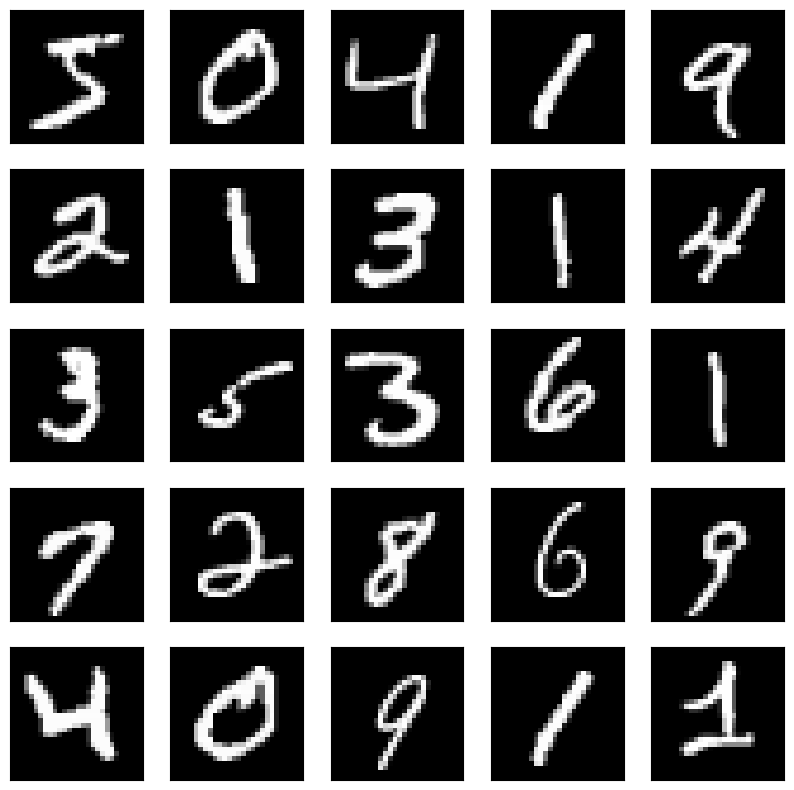

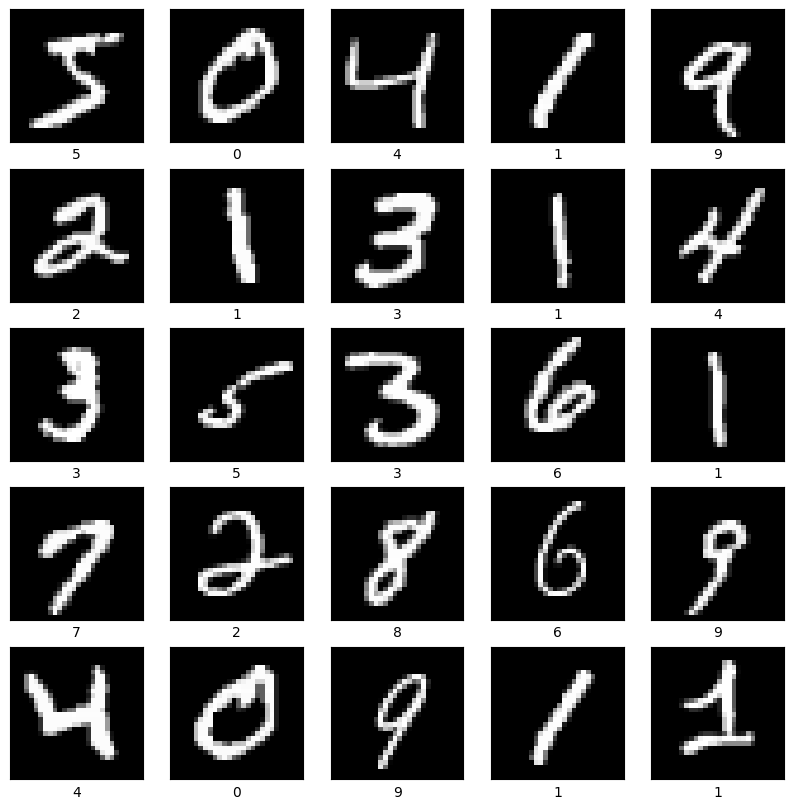

In [20]:
def show_mnist_without_label():
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(x_train[i], cmap="gray")

def show_mnist_with_label():
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(x_train[i], cmap="gray")
        plt.xlabel(y_train[i])

show_mnist_without_label()
show_mnist_with_label()

In [21]:
def create_model(input_shape1, input_shape2, output_shape, activation):
    model = tf.keras.models.Sequential([
      tf.keras.layers.Flatten(input_shape=(input_shape1, input_shape2)),
      tf.keras.layers.Dense(output_shape, activation=activation),
      tf.keras.layers.Dropout(0.4),
      tf.keras.layers.Dense(10)
    ])
    return model

mymodel = create_model(28, 28, 128, 'relu')
mymodel.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
predictions = mymodel(x_train[:1]).numpy()
predictions

array([[ 0.23558488, -0.35380113, -1.0261023 ,  0.09292716, -0.28509665,
         0.3965924 , -0.04234209, -0.25998172,  0.17521541,  0.09799268]],
      dtype=float32)

In [23]:
tf.nn.softmax(predictions).numpy()

array([[0.13066511, 0.07247573, 0.03700121, 0.1132933 , 0.07763017,
        0.15349151, 0.09895951, 0.07960454, 0.12301032, 0.11386864]],
      dtype=float32)

In [24]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [25]:
loss_fn(y_train[:1], predictions).numpy()

1.87411

In [26]:
mymodel.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [27]:
log_dir = "/workspace/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)

In [28]:
mymodel.fit(
    x_train, 
    y_train, 
    epochs=30, 
    validation_split=0.25, 
    verbose=2,
    callbacks=[tensorboard_callback]
)

Epoch 1/30
1407/1407 - 6s - loss: 0.3835 - accuracy: 0.8871 - val_loss: 0.1796 - val_accuracy: 0.9472 - 6s/epoch - 4ms/step
Epoch 2/30
1407/1407 - 7s - loss: 0.2047 - accuracy: 0.9386 - val_loss: 0.1361 - val_accuracy: 0.9599 - 7s/epoch - 5ms/step
Epoch 3/30
1407/1407 - 6s - loss: 0.1618 - accuracy: 0.9517 - val_loss: 0.1218 - val_accuracy: 0.9636 - 6s/epoch - 5ms/step
Epoch 4/30
1407/1407 - 6s - loss: 0.1389 - accuracy: 0.9585 - val_loss: 0.1092 - val_accuracy: 0.9670 - 6s/epoch - 4ms/step
Epoch 5/30
1407/1407 - 6s - loss: 0.1274 - accuracy: 0.9599 - val_loss: 0.1001 - val_accuracy: 0.9713 - 6s/epoch - 4ms/step
Epoch 6/30
1407/1407 - 9s - loss: 0.1126 - accuracy: 0.9644 - val_loss: 0.1023 - val_accuracy: 0.9693 - 9s/epoch - 6ms/step
Epoch 7/30
1407/1407 - 6s - loss: 0.1005 - accuracy: 0.9678 - val_loss: 0.0969 - val_accuracy: 0.9718 - 6s/epoch - 4ms/step
Epoch 8/30
1407/1407 - 7s - loss: 0.0960 - accuracy: 0.9696 - val_loss: 0.0938 - val_accuracy: 0.9733 - 7s/epoch - 5ms/step
Epoch 9/

In [29]:
mymodel.evaluate(x_test,  y_test, verbose=2)

313/313 - 3s - loss: 0.0942 - accuracy: 0.9797 - 3s/epoch - 10ms/step


[0.09417790174484253, 0.9797000288963318]

In [44]:
tf.keras.losses.get('loss').numpy()

#loss
# plt.plot(mymodel.history.history['loss'])
# plt.plot(mymodel.history.history['val_loss'])
# plt.title('model loss')
# plt.ylabel('loss')
# plt.xlabel('epoch')
# plt.show()
#
# #accuracy
# plt.plot(mymodel.history.history['accuracy'])
# plt.plot(mymodel.history.history['val_accuracy'])
# plt.title('model accuracy')
# plt.ylabel('accuracy')
# plt.xlabel('epoch')
# plt.show()

ValueError: Unknown loss function: 'loss'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

In [ ]:
print(f"Répertoire actuel : {os.getcwd()}")
os.makedirs('model', exist_ok=True)
mymodel.save(os.path.join('model', 'my_model.keras'))

In [ ]:
print(os.listdir('/tf'))

In [ ]:
probability_model = tf.keras.Sequential([
  mymodel,
  tf.keras.layers.Softmax()
])

In [ ]:
probability_model(x_test[:5])